# Selling Cadence Experiment (V1)

Research notebook for `experiments/pricing_cadence_lib.py`. **`main.py` is
untouched** - every variant here (A/B/C/D) is a standalone agent file under
`experiments/pricing_cadence_variants/`. Full writeup:
[`experiments/pricing_cadence_experiment_report.md`](pricing_cadence_experiment_report.md).

## The research question

Not "which crop has the highest current price" (that's `choose_crop`'s job,
already forward-priced). This is about the shed: **given inventory pressure,
town demand, opponent supply, harvest timing, and remaining season, should we
sell what we're holding right now, or wait?**

## What already existed (assessed before writing any new code)

- `pricing.py` / the inlined copy in `main.py`: an engine-verified
  `market_price()`, per-unit price-path simulation, and town-demand
  simulation. Sufficient - nothing here needed re-deriving.
- `estimate_future_price()`: forward price at a horizon, given our own and
  the opponent's *visible* pipeline (their planted tiles - their shed stays
  invisible, so it's a lower bound). Two pessimistic simplifications: supply
  lands all at once at turn 0, and no future shop unlocks are modelled.
- `recommend_sell_quantity()`: sizes an order against a *given* acceptance
  price. It has no opinion on what that price should be.
- `should_sell()`: still a flat, state-blind per-product constant
  (`SELL_PRICE_THRESHOLDS`). **This is the gap** - nothing compares today's
  price against what the model itself predicts a few days out, nothing
  scales urgency by how much is piled up, and `LIQUIDATION_START_DAY` (a
  single hard day cutoff) is the only cadence concept that exists at all.

`docs/REPLAY_ANALYSIS.md` (already in the repo, verified against real ladder
replays) ranks selling cadence **last** of six identified gaps - the agent is
still at ~25 tiles / ~6 units against the replay's 75 tiles / 13-15 units, so
these results describe cadence *at the current scale*, not the ladder's.

## 1. Setup

In [1]:
import sys
import pathlib

REPO = pathlib.Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "experiments"))

import pricing
import pricing_cadence_lib as cadence

import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
from kaggle_environments import make

In [2]:
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_MUTED = "#52514e"
GRID = "#e5e4e0"

PLANTABLE_CROPS = ["WHEAT", "CARROT", "TOMATO", "STRAWBERRY", "MELON"]
CROP_COLORS = dict(zip(
    PLANTABLE_CROPS,
    ["#2a78d6", "#eb6834", "#c23b6b", "#1baf7a", "#8a5fd1"],
))
VARIANT_COLORS = {"A": INK_MUTED, "B": "#2a78d6", "C": "#eb6834", "D": "#1baf7a"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_MUTED,
    "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "font.size": 10, "figure.dpi": 110,
})


def finish(ax, title, xlabel=None, ylabel=None, legend=False):
    ax.set_title(title, fontsize=12.5, color=INK, pad=12, loc="left")
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if legend: ax.legend(frameon=False, labelcolor=INK_MUTED)
    plt.tight_layout()


def label_series_ends(ax, x_end, values_by_label, x_data_end=None, min_gap_frac=0.032):
    x_data_end = x_end if x_data_end is None else x_data_end
    lo, hi = ax.get_ylim()
    min_gap = (hi - lo) * min_gap_frac
    order = sorted(values_by_label.items(), key=lambda kv: kv[1])
    placed = []
    for label, value in order:
        pos = value
        if placed and pos - placed[-1] < min_gap:
            pos = placed[-1] + min_gap
        placed.append(pos)
        if abs(pos - value) > 1e-9:
            ax.plot([x_data_end, x_end], [value, pos], color=INK_MUTED, linewidth=0.7, zorder=2)
        ax.text(x_end + (hi - lo) * 0.003, pos, label, va="center", fontsize=9, color=INK)

## 2. Diagnostic 1 - Price vs inventory

Recap from `notebooks/pricing_analysis_v0.ipynb` (glut side only - see that
notebook for the scarcity-side hinge blowup and why it's practically
unreachable). This is the ground truth every other chart here builds on.

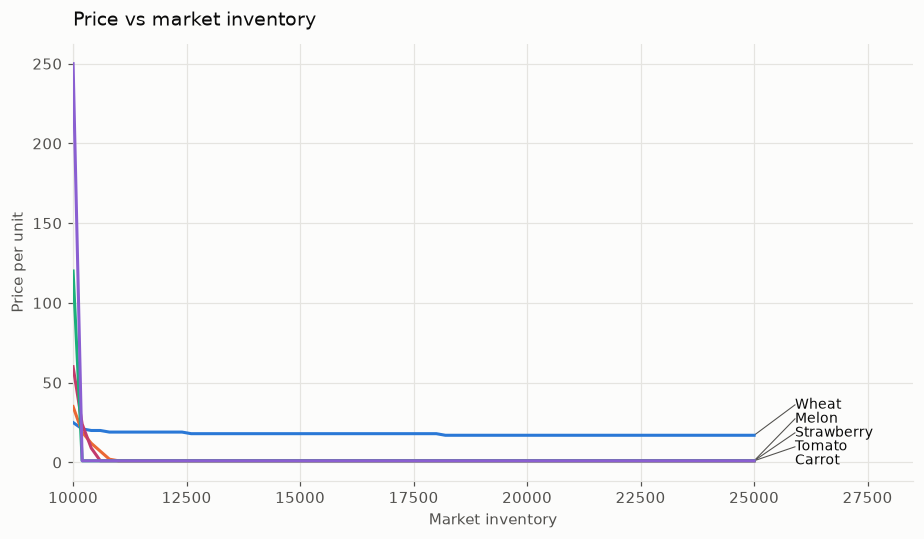

In [3]:
inventories = range(10000, 25001, 200)
fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    prices = [pricing.market_price(crop, inv) for inv in inventories]
    ax.plot(list(inventories), prices, color=CROP_COLORS[crop], linewidth=2, zorder=3)
    end_values[crop.title()] = prices[-1]
ax.set_xlim(10000, 28500)
label_series_ends(ax, 25900, end_values, x_data_end=25000)
finish(ax, "Price vs market inventory", xlabel="Market inventory", ylabel="Price per unit")
plt.show()

## 3. Diagnostic 2 - Expected future price vs current price

`estimate_sell_or_hold_value()`'s core comparison, swept over how much of
our own supply is still in the pipeline. At zero pipeline, town demand alone
over the `SELL_HORIZON_DAYS` window barely moves price - holding briefly
costs nothing. A heavy pipeline crashes the *hold* value hard: the model is
telling us our own upcoming harvest is the thing to sell ahead of.

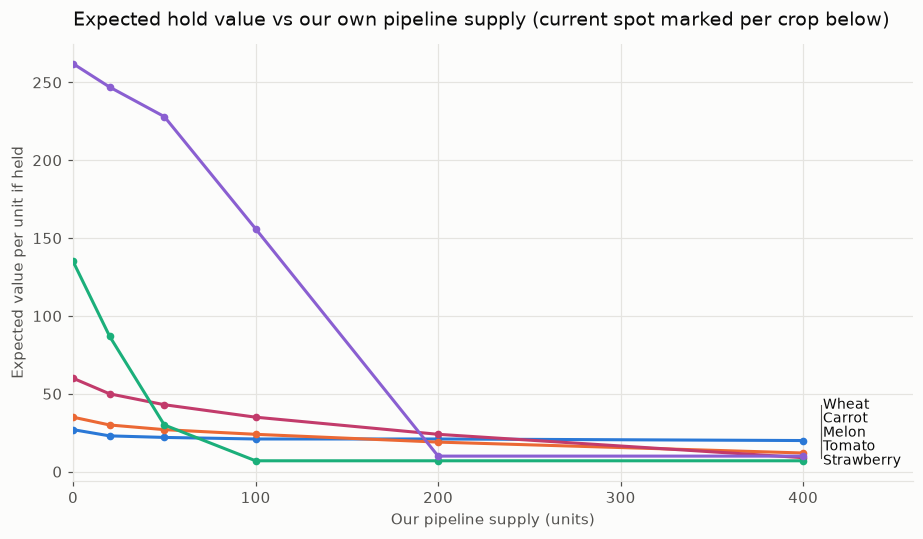

,current_spot
crop,
WHEAT,25
CARROT,35
TOMATO,60
STRAWBERRY,120
MELON,250


In [4]:
pipeline_sizes = [0, 20, 50, 100, 200, 400]
fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    current = pricing.market_price(crop, 10000)
    hold_values = [
        cadence.estimate_sell_or_hold_value(crop, 10, 10000, day=10, pipeline_supply=p)["value_hold_per_unit"]
        for p in pipeline_sizes
    ]
    ax.plot(pipeline_sizes, hold_values, color=CROP_COLORS[crop], linewidth=2, marker="o", markersize=4, zorder=3)
    end_values[crop.title()] = hold_values[-1]
ax.set_xlim(0, 460)
label_series_ends(ax, 410, end_values)
finish(ax, "Expected hold value vs our own pipeline supply (current spot marked per crop below)",
       xlabel="Our pipeline supply (units)", ylabel="Expected value per unit if held")
plt.show()

pd.DataFrame({
    "crop": PLANTABLE_CROPS,
    "current_spot": [pricing.market_price(c, 10000) for c in PLANTABLE_CROPS],
}).set_index("crop")

## 4. Diagnostic 3 - Sell quantity vs inventory pressure

Variant D's full mechanic (pressure lowers the acceptance price, urgency
lowers it further *and* raises the per-turn cap) applied across the season
for a fixed, large MELON pile (150 units - 10x its 15/turn cap, so it cannot
structurally clear without both effects). At low pressure the flat cap binds
regardless of price; once urgency starts lifting that cap too, quantity
actually moves - this is the mechanism, not just the acceptance price.

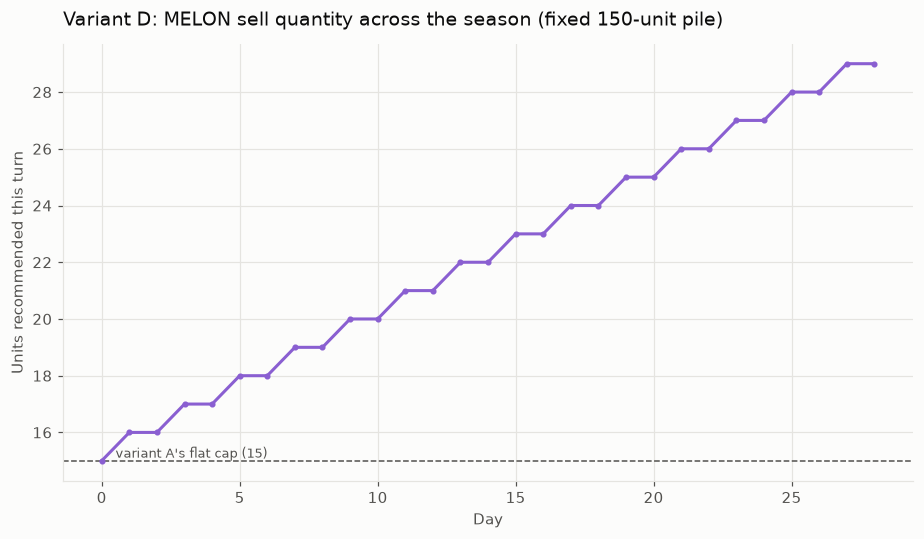

In [5]:
PILE = 150
days_range = list(range(0, 29))
quantities = []
for day in days_range:
    remaining = 30 - 1 - day
    pressure = cadence.inventory_pressure("MELON", PILE, 0, remaining_days=remaining)
    min_price = pricing.market_price("MELON", 10000) / (1 + cadence.INVENTORY_PRESSURE_WEIGHT * pressure)
    urgency = cadence.cadence_urgency(day)
    min_price = min_price * (1 - cadence.CADENCE_URGENCY_PRICE_WEIGHT * urgency)
    cap = max(1, round(cadence.MAX_SELL_PER_TURN["MELON"] * (1 + cadence.CADENCE_URGENCY_CAP_WEIGHT * urgency)))
    qty = pricing.recommend_sell_quantity("MELON", 10000, PILE, min_acceptable_price=max(1, min_price), max_per_turn=cap)
    quantities.append(qty)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(days_range, quantities, color=CROP_COLORS["MELON"], linewidth=2, marker="o", markersize=3, zorder=3)
ax.axhline(cadence.MAX_SELL_PER_TURN["MELON"], color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
ax.text(0.5, cadence.MAX_SELL_PER_TURN["MELON"], "variant A's flat cap (15)", va="bottom", fontsize=8.5, color=INK_MUTED)
finish(ax, f"Variant D: MELON sell quantity across the season (fixed {PILE}-unit pile)",
       xlabel="Day", ylabel="Units recommended this turn")
plt.show()

## 5. A real contested episode - variant D vs A, seed 0

The remaining diagnostics need an actual trace, not a swept function - so
this runs one real head-to-head episode (the sharpest variant, D, against the
unmodified control, A) and records per-day state exactly like
`notebooks/washamba_bots_experiments_v0.ipynb`'s `profile_episode` does.

In [6]:
def profile_episode(agent_a_path, agent_b_path, seed):
    env = make("kaggriculture", configuration={"episodeSteps": 720, "seed": seed}, debug=False)
    env.run([agent_a_path, agent_b_path])
    turns_per_day = 24
    history = []
    sold_units_by_day = []
    orders_per_day = Counter()
    for index, step in enumerate(env.steps):
        action = step[0].get("action") or {}
        day = index // turns_per_day
        for order in action.get("market") or []:
            if order and order[0] == "SELL" and len(order) >= 3:
                obs_now = step[0].observation
                price_now = obs_now["market"]["prices"].get(order[1], 0)
                sold_units_by_day.append({
                    "day": day, "product": order[1], "quantity": order[2],
                    "revenue": order[2] * price_now,
                })
                orders_per_day[day] += 1
        if index % turns_per_day == 0:
            obs0 = step[0].observation
            history.append({
                "day": day,
                "bank_a": obs0["farms"][0]["money"],
                "bank_b": obs0["farms"][1]["money"],
                **{f"price_{k}": v for k, v in obs0["market"]["prices"].items()},
                **{f"inv_{k}": v for k, v in obs0["market"]["inventory"].items()},
            })
    final = env.steps[-1]
    return {
        "balance_a": final[0].reward, "balance_b": final[1].reward,
        "history": pd.DataFrame(history).set_index("day"),
        "sales": pd.DataFrame(sold_units_by_day),
        "orders_per_day": orders_per_day,
    }


profile = profile_episode(
    str(REPO / "experiments/pricing_cadence_variants/agent_d.py"),
    str(REPO / "experiments/pricing_cadence_variants/agent_a.py"),
    seed=0,
)
timeline = profile["history"]
sales = profile["sales"]
print(f"D (seat 0): {profile['balance_a']:,.0f}   A (seat 1): {profile['balance_b']:,.0f}")

D (seat 0): 42,106   A (seat 1): 40,369


## 6. Diagnostic 4 - Sales per day

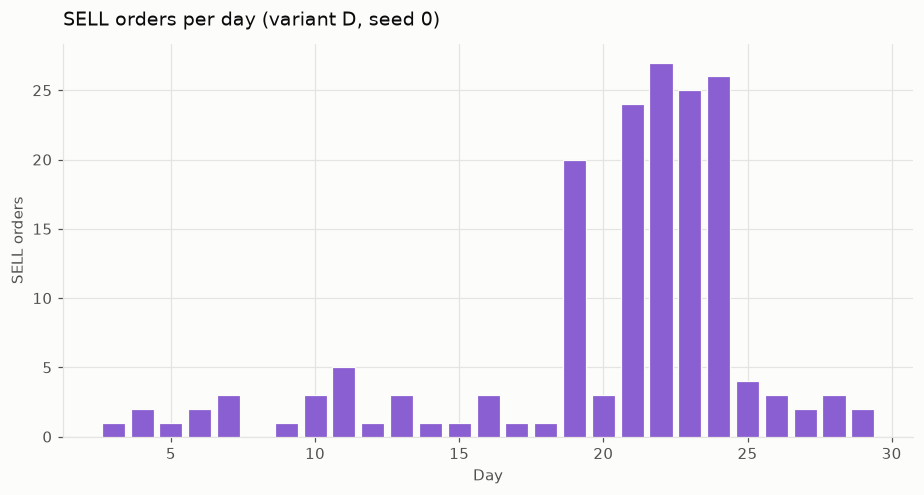

In [7]:
sales_per_day = sales.groupby("day")["quantity"].count() if not sales.empty else pd.Series(dtype=float)
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(sales_per_day.index, sales_per_day.values, color=CROP_COLORS["MELON"], edgecolor=SURFACE, linewidth=0.8, zorder=3)
finish(ax, "SELL orders per day (variant D, seed 0)", xlabel="Day", ylabel="SELL orders")
plt.show()

## 7. Diagnostic 5 - Market inventory by crop over time

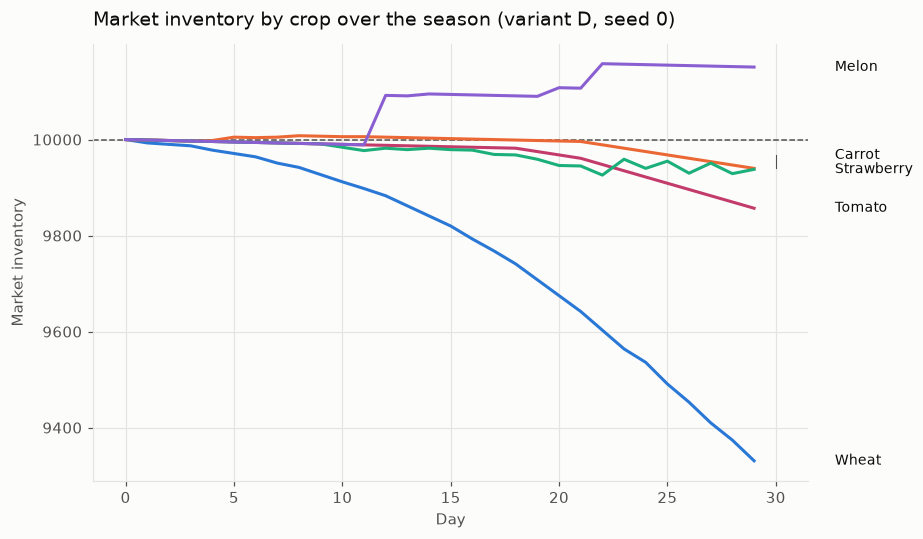

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    col = f"inv_{crop}"
    if col not in timeline.columns:
        continue
    ax.plot(timeline.index, timeline[col], color=CROP_COLORS[crop], linewidth=2, zorder=3)
    end_values[crop.title()] = timeline[col].iloc[-1]
ax.axhline(10000, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
label_series_ends(ax, timeline.index[-1] + 1, end_values)
finish(ax, "Market inventory by crop over the season (variant D, seed 0)",
       xlabel="Day", ylabel="Market inventory")
plt.show()

## 8. Diagnostic 6 - Revenue by crop

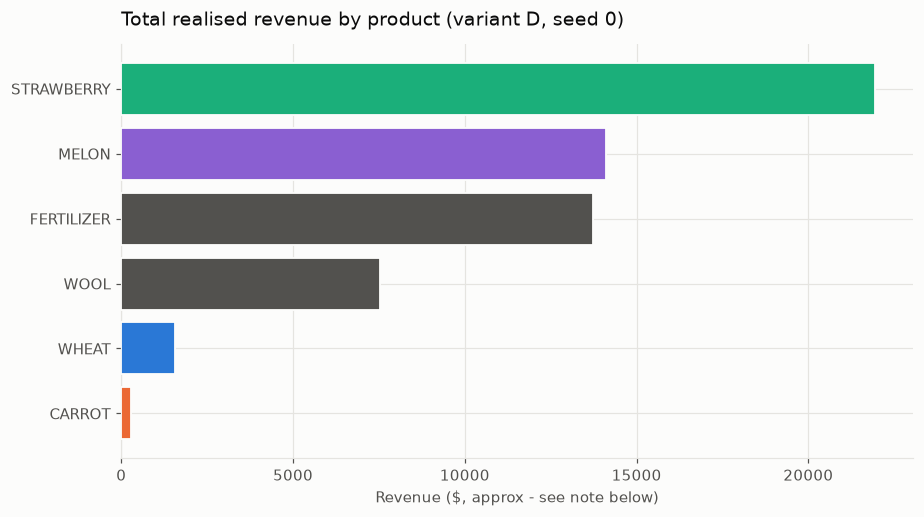

In [9]:
revenue_by_crop = sales.groupby("product")["revenue"].sum().sort_values() if not sales.empty else pd.Series(dtype=float)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
colors = [CROP_COLORS.get(p, INK_MUTED) for p in revenue_by_crop.index]
ax.barh(revenue_by_crop.index, revenue_by_crop.values, color=colors, edgecolor=SURFACE, linewidth=1.2, zorder=3)
finish(ax, "Total realised revenue by product (variant D, seed 0)", xlabel="Revenue ($, approx - see note below)")
plt.show()

Revenue here is `order quantity x price at the turn the order was issued` -
an approximation (a multi-unit order's later units sell for slightly less as
the price path decays within the order), consistent with how the sibling
notebook already treats submitted quantities as an upper bound.

## 9. Diagnostic 7 - Price trajectory by crop

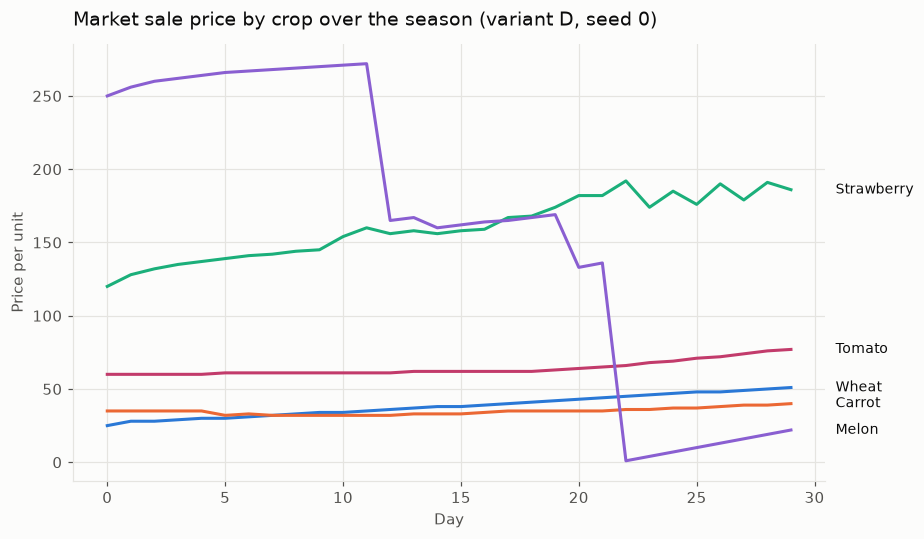

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5))
end_values = {}
for crop in PLANTABLE_CROPS:
    col = f"price_{crop}"
    if col not in timeline.columns:
        continue
    ax.plot(timeline.index, timeline[col], color=CROP_COLORS[crop], linewidth=2, zorder=3)
    end_values[crop.title()] = timeline[col].iloc[-1]
label_series_ends(ax, timeline.index[-1] + 1, end_values)
finish(ax, "Market sale price by crop over the season (variant D, seed 0)",
       xlabel="Day", ylabel="Price per unit")
plt.show()

## 10. Diagnostic 8 - Cumulative realised revenue

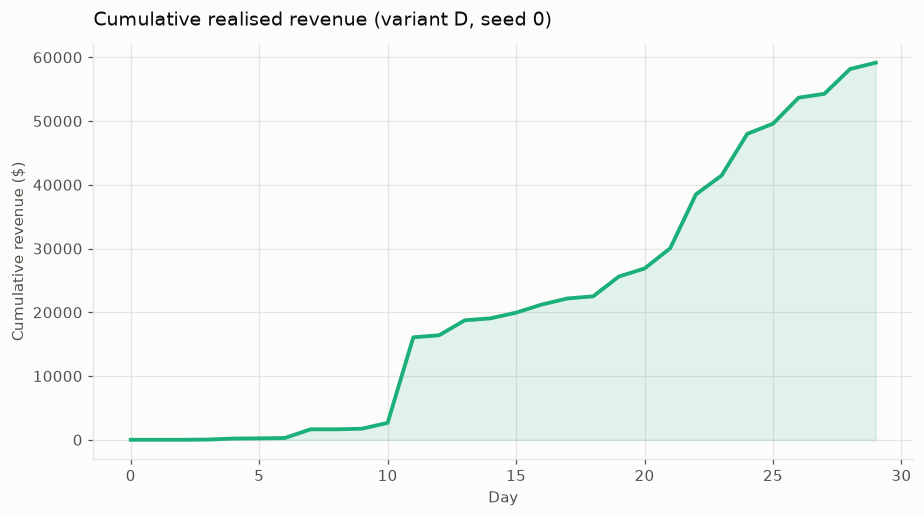

In [11]:
cumulative = sales.groupby("day")["revenue"].sum().reindex(range(30), fill_value=0).cumsum() if not sales.empty else pd.Series(dtype=float)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(cumulative.index, cumulative.values, color=VARIANT_COLORS["D"], linewidth=2.5, zorder=3)
ax.fill_between(cumulative.index, 0, cumulative.values, color=VARIANT_COLORS["D"], alpha=0.12, zorder=2)
finish(ax, "Cumulative realised revenue (variant D, seed 0)", xlabel="Day", ylabel="Cumulative revenue ($)")
plt.show()

## 11. Benchmark - A/B/C/D head to head, paired seat-swapped, 12 seeds

`experiments/head_to_head.py`'s exact methodology per `docs/CHECKPOINTS.md`
(anything about selling needs a contested market - the built-ins never
sell, so a market-timing change looks free against them). Each variant plays
the unmodified control (A) on the same 12 seeds, both seats, seat advantage
cancelled by swapping and averaging.

In [12]:
import json
with open(REPO / "experiments/pricing_cadence_benchmark_results.json") as f:
    bench = json.load(f)

summary = pd.DataFrame({
    letter: {
        "mean": row["mean"], "median": row["median"], "stdev": row["stdev"],
        "best": row["best"], "worst": row["worst"],
        "wins": f"{row['wins']}/{row['matches']}",
    }
    for letter, row in bench.items()
}).T
summary.index.name = "variant"
summary

,mean,median,stdev,best,worst,wins
variant,,,,,,
B,1118.416667,441.0,2056.2152,5917.0,-1499.0,21/24
C,403.333333,317.5,388.239803,1304.0,-342.0,22/24
D,1571.041667,1597.0,209.394049,1956.0,999.0,24/24


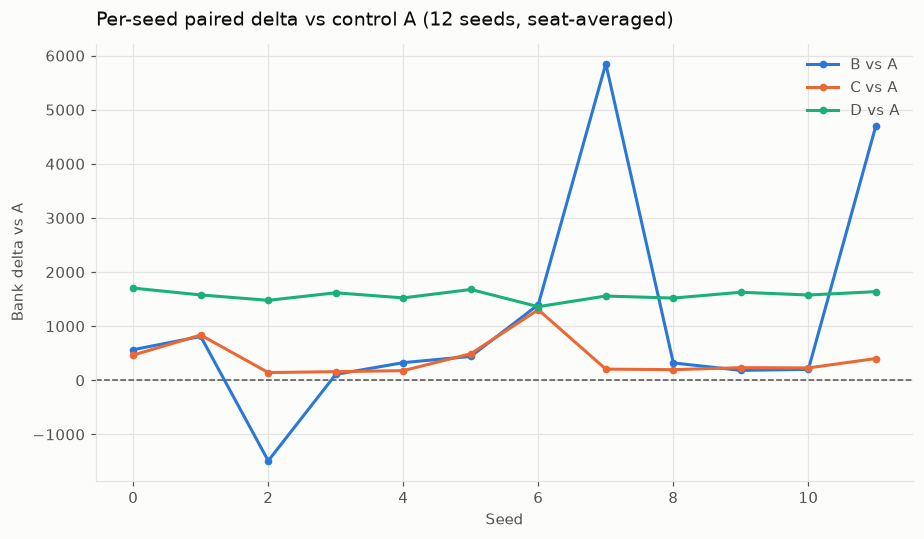

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5))
for letter in ["B", "C", "D"]:
    per_seed = bench[letter]["per_seed"]
    seeds = [row["seed"] for row in per_seed]
    deltas = [row["paired_delta_mean"] for row in per_seed]
    ax.plot(seeds, deltas, color=VARIANT_COLORS[letter], linewidth=2, marker="o", markersize=4, zorder=3, label=f"{letter} vs A")
ax.axhline(0, color=INK_MUTED, linestyle="--", linewidth=1, zorder=1)
finish(ax, "Per-seed paired delta vs control A (12 seeds, seat-averaged)",
       xlabel="Seed", ylabel="Bank delta vs A", legend=True)
plt.show()

**D wins all 24 of 24 matches**, with the lowest variance of the three (209
vs B's 2,056) and every single seed positive - even its worst seed (+999) is
a clear win. B has the highest mean but is driven by two large outlier seeds
(seeds 7 and 11) and loses seed 2 outright. C is the most modest gain but the
most consistent of the two forward-price variants. Adding the cadence/urgency
term (D) is what turns an inconsistent gain into a robust one.